# Análise Exploratória — UNESCO World Heritage Sites

Análise inicial do dataset `whc001.csv` com o objetivo de entender a estrutura dos dados, identificar colunas relevantes e avaliar qualidade (valores ausentes, tipos, cardinalidade).

**Objetivos do projeto:**
- Análise de densidade e clusters regionais (DBSCAN / KMeans)
- Evolução temporal por décadas
- Similaridade entre sítios por NLP
- Dashboard de critérios de inscrição

## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

## 2. Carregamento dos Dados

In [2]:
DATA_PATH = Path("..") / "data" / "raw" / "whc001.csv"

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8")

print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Shape: 1,248 linhas × 54 colunas


## 3. Visão Geral do Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 54 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name_en                1248 non-null   object 
 1   name_fr                1248 non-null   object 
 2   name_es                1245 non-null   object 
 3   name_ru                1128 non-null   object 
 4   name_ar                1141 non-null   object 
 5   name_zh                1081 non-null   object 
 6   short_description_en   1248 non-null   object 
 7   short_description_fr   1248 non-null   object 
 8   short_description_es   1223 non-null   object 
 9   short_description_ru   1135 non-null   object 
 10  short_description_ar   1145 non-null   object 
 11  short_description_zh   1078 non-null   object 
 12  description_en         1248 non-null   object 
 13  justification_en       1198 non-null   object 
 14  date_inscribed         1248 non-null   int64  
 15  seco

In [4]:
df.head()

,name_en,name_fr,name_es,name_ru,name_ar,name_zh,short_description_en,short_description_fr,short_description_es,short_description_ru,short_description_ar,short_description_zh,description_en,justification_en,date_inscribed,secondary_dates,danger,date_end,danger_list,area_hectares,cultural_criteria,natural_criteria,criteria_txt,category,category_id,states_names,iso_codes,region,region_code,transboundary,main_image_url,main_image_author,main_image_copyright,main_image_caption_en,main_image_caption_fr,main_image_caption_es,main_image_caption_ru,main_image_caption_ar,main_image_caption_zh,images_urls,uuid,id_no,coordinates,main_video_url,main_video_author,main_video_caption_en,main_video_caption_fr,main_video_caption_es,main_video_caption_ru,main_video_caption_ar,main_video_caption_zh,videos_urls,components_list,components_count
0,Natural and Cultural Heritage of the Ohrid region,Patrimoine naturel et culturel de la région d’Ohrid,Patrimonio natural y cultural de la región de Ohrid,Природное и культурное наследие Охридского региона,التراث الطبيعي والثقافي في منطقة أوخريد,奥赫里德地区自然与文化遗产,"A superlative natural phenomenon, Lake Ohrid provides a refuge for numerous ...","Phénomène naturel exceptionnel, le lac d’Ohrid sert de refuge à de nombreuse...",En 1979 se inscribió en la Lista del Patrimonio Mundial el sitio formado por...,Город Охрид и часть Охридского озера в Северной Македонии входят в Список об...,تُعتبر مدينة أوريد التي تمّ بناؤها على ضفاف بحيرة أوريد، من أقدم المنشآت الت...,北马其顿奥赫里德湖区及其腹地（包括奥赫里德市）于1979年被列入《世界遗产名录》。拓界后的遗址将覆盖位于阿尔巴尼亚境内的奥赫里德湖区、位于该湖西北部的L...,"A superlative natural phenomenon, Lake Ohrid provides a refuge for numerous ...","Brief synthesis The Lake Ohrid region, a mixed World Heritage property cover...",1979,"1979, 2019,1980",False,NaN,NaN,94728.60,"c1, c3, c4",n7,(i)(iii)(iv)(vii),Mixed,3,"North Macedonia,Albania","MK, AL",Europe and North America,EUR,True,https://whc.unesco.org/document/108890,Graciela Gonzalez Brigas,Graciela Gonzalez Brigas,Natural and Cultural Heritage of the Ohrid region (North Macedonia),Patrimoine naturel et culturel de la région d’Ohrid (Macédoine du Nord),NaN,NaN,NaN,NaN,"https://whc.unesco.org/document/108890, https://whc.unesco.org/document/1088...",446d230f-06f6-5294-acf5-c6f64ee26f19,99,"40.9918333333,20.7041666667",https://www.youtube-nocookie.com/embed/a33C_MYltqY,NHK Nippon Hoso Kyokai,"Situated on the shores of Lake Ohrid, the town of Ohrid is one of the oldest...",NaN,NaN,NaN,NaN,NaN,https://www.youtube-nocookie.com/embed/a33C_MYltqY,"{name: Natural and Cultural Heritage of the Ohrid Region, ref: 99quater-001,...",2
1,Tipasa,Tipasa,Tipasa,Древний город Типаса,تيبازا,提帕萨,"On the shores of the Mediterranean, Tipasa was an ancient Punic trading-post...","Sur les rives de la Méditerranée, Tipasa, ancien comptoir punique, fut occup...","Situada en la costa del Mediterráneo, Tipasa fue una factoría cartaginesa co...",Находящаяся на средиземноморском побережье Типаса была древним пуническим то...,تقع تيبازا على ضفاف البحر المتوسط وهي مركز تجاري بوني (قرطاجي) قديم. احتلّها...,提帕萨位于地中海海滨，原是古罗马统治下古迦太基人的贸易港，后成为征服毛利塔尼亚王国的战略基地。该遗址不仅有一系列腓尼基人、罗马人、古基督教和拜占庭时期的...,"On the shores of the Mediterranean, Tipasa was an ancient Punic trading-post...",Brief synthesis Tipasa is located 70 km west of Algiers. It is a serial prop...,1982,1982,False,NaN,NaN,52.16,"c3, c4",NaN,(iii)(iv),Cultural,1,Algeria,DZ,Arab States,ARB,False,https://whc.unesco.org/document/109049,Giovanni Boccardi,UNESCO,Tipasa (Algeria),Tipasa (Algerie),NaN,NaN,NaN,NaN,"https://whc.unesco.org/document/109049, https://whc.unesco.org/document/1090...",02ce240b-9114-5858-8c68-7f65fa93c789,193,"36.55,2.383333333",https://www.youtube-nocookie.com/embed/Y3kdAi7mMhg,NHK Nippon Hoso Kyokai,"On the shores of the Mediterranean, Tipasa was an ancient Punic trading-post...",NaN,NaN,NaN,NaN,NaN,https://www.youtube-nocookie.com/embed/Y3kdAi7mMhg,"{name: Mausoleum Kbor er Roumia, ref: 193-003, latitude: 36.5748333333, long...",3
2,Antigua Naval Dockya

## 4. Colunas do Dataset

Tabela consolidada com todas as colunas, seus tipos e contagem de valores ausentes — base para decidir quais colunas manter ou descartar.

In [5]:
column_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "sample_value": df.iloc[0],
})

column_summary

,dtype,non_null,null_count,null_pct,n_unique,sample_value
name_en,object,1248,0,0.00,1248,Natural and Cultural Heritage of the Ohrid region
name_fr,object,1248,0,0.00,1248,Patrimoine naturel et culturel de la région d’Ohrid
name_es,object,1245,3,0.24,1245,Patrimonio natural y cultural de la región de Ohrid
name_ru,object,1128,120,9.62,1126,Природное и культурное наследие Охридского региона
name_ar,object,1141,107,8.57,1140,التراث الطبيعي والثقافي في منطقة أوخريد
name_zh,object,1081,167,13.38,1079,奥赫里德地区自然与文化遗产
short_description_en,object,1248,0,0.00,1248,"A superlative natural phenomenon, Lake Ohrid provides a refuge for numerous ..."
short_description_fr,object,1248,0,0.00,1248,"Phénomène naturel exceptionnel, le lac d’Ohrid sert de refuge à de nombreuse..."
short_description_es,object,1223,25,2.00,1220,En 1979 se inscribió en la Lista del Patrimonio Mundial el sitio formado por...
short_description_ru,object,1135,113,9.05,1133,Город Охрид и часть Охридского озера в Северной Македонии входят в Список об...


## 5. Valores Ausentes

Foco nas colunas com ausências para facilitar a decisão de descarte ou imputação.

In [6]:
missing = (
    df.isnull().sum()
    .rename("null_count")
    .to_frame()
    .assign(null_pct=lambda x: (x["null_count"] / len(df) * 100).round(2))
    .query("null_count > 0")
    .sort_values("null_pct", ascending=False)
)

print(f"{len(missing)} colunas com valores ausentes (de {df.shape[1]} total)\n")
missing

37 colunas com valores ausentes (de 54 total)



,null_count,null_pct
main_image_caption_zh,1248,100.00
main_video_caption_zh,1248,100.00
main_image_caption_ru,1248,100.00
main_image_caption_ar,1248,100.00
date_end,1248,100.00
main_image_caption_es,1248,100.00
main_video_caption_ar,1247,99.92
main_video_caption_ru,1245,99.76
main_video_caption_es,1204,96.47
danger_list,1195,95.75


## 6. Estatísticas Descritivas

Resumo das colunas numéricas.

In [7]:
df.describe()

,date_inscribed,date_end,area_hectares,category_id,main_image_caption_es,main_image_caption_ru,main_image_caption_ar,main_image_caption_zh,id_no,main_video_caption_zh,components_count
count,1248.000000,0.0,1.227000e+03,1248.000000,0.0,0.0,0.0,0.0,1248.000000,0.0,1248.000000
mean,2000.424679,NaN,3.930498e+05,1.254006,NaN,NaN,NaN,NaN,886.329327,NaN,4.982372
std,13.465299,NaN,5.144636e+06,0.505368,NaN,NaN,NaN,NaN,503.550663,NaN,27.273300
min,1978.000000,NaN,0.000000e+00,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000
25%,1988.750000,NaN,2.219000e+01,1.000000,NaN,NaN,NaN,NaN,447.750000,NaN,1.000000
50%,1999.000000,NaN,2.583000e+02,1.000000,NaN,NaN,NaN,NaN,876.500000,NaN,1.000000
75%,2012.000000,NaN,1.480000e+04,1.000000,NaN,NaN,NaN,NaN,1333.250000,NaN,3.000000
max,2025.000000,NaN,1.662671e+08,3.000000,NaN,NaN,NaN,NaN,1749.000000,NaN,758.000000


## 7. Remoção de Colunas Não-Inglesas

As versões em francês, espanhol, russo, árabe e chinês não serão utilizadas no projeto. Mantemos apenas as colunas em inglês.

In [8]:
cols_to_drop = [
    "name_fr", "name_es", "name_ru", "name_ar", "name_zh",
    "short_description_fr", "short_description_es", "short_description_ru",
    "short_description_ar", "short_description_zh",
    "main_image_caption_fr", "main_image_caption_es", "main_image_caption_ru",
    "main_image_caption_ar", "main_image_caption_zh",
    "main_video_caption_fr", "main_video_caption_es", "main_video_caption_ru",
    "main_video_caption_ar", "main_video_caption_zh",
]

existing = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=existing)

print(f"Colunas removidas : {len(existing)}")
print(f"Shape após remoção: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Colunas removidas : 20
Shape após remoção: 1,248 linhas × 34 colunas


## 8. Feature Engineering

Criação de features derivadas orientadas pelos objetivos do projeto:

| Feature | Origem | Uso |
|---|---|---|
| `year_inscribed` | `date_inscribed` | Série temporal, correlações |
| `decade_inscribed` | `year_inscribed` | Agrupamento por décadas |
| `years_on_list` | `year_inscribed` | Antiguidade do sítio |
| `n_cultural_criteria` | `cultural_criteria` (texto) | Dashboard de critérios |
| `n_natural_criteria` | `natural_criteria` (texto) | Dashboard de critérios |
| `n_criteria` | soma total | Clustering, dashboard |
| `is_endangered` | `danger` (bool) | Análise de risco |
| `description_word_count` | `short_description_en` | Proxy de riqueza textual (NLP) |
| `full_text` | `name_en` + descrição | Corpus para NLP |
| `latitude` / `longitude` | `coordinates` (string `"lat,lon"`) | Clustering geográfico |
| `has_coordinates` | `latitude` / `longitude` | Filtragem para clustering |

In [10]:
# --- Temporal ---
df["year_inscribed"] = pd.to_numeric(df["date_inscribed"], errors="coerce").astype("Int64")
df["decade_inscribed"] = (df["year_inscribed"] // 10 * 10).astype("Int64")
df["years_on_list"] = (2024 - df["year_inscribed"]).astype("Int64")

# --- Critérios (contagem a partir das colunas de texto) ---
def count_criteria(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .str.split(",")
        .apply(lambda parts: sum(1 for p in parts if p.strip()))
    )

df["n_cultural_criteria"] = count_criteria(df["cultural_criteria"])
df["n_natural_criteria"] = count_criteria(df["natural_criteria"])
df["n_criteria"] = df["n_cultural_criteria"] + df["n_natural_criteria"]

# --- Perigo (já é bool) ---
df["is_endangered"] = df["danger"]

# --- NLP ---
df["description_word_count"] = (
    df["short_description_en"].str.split().str.len().fillna(0).astype(int)
)
df["full_text"] = (
    df["name_en"].fillna("") + " " + df["short_description_en"].fillna("")
).str.strip()

# --- Geográfico (parse da coluna 'coordinates') ---
_coords = df["coordinates"].str.split(",", expand=True)
df["latitude"] = pd.to_numeric(_coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(_coords[1], errors="coerce")
df["has_coordinates"] = df["latitude"].notna() & df["longitude"].notna()

print(f"Coordenadas válidas: {df['has_coordinates'].sum():,} / {len(df):,}")

Coordenadas válidas: 1,247 / 1,248


In [11]:
new_features = [
    "year_inscribed", "decade_inscribed", "years_on_list",
    "n_cultural_criteria", "n_natural_criteria", "n_criteria",
    "is_endangered", "description_word_count", "has_coordinates",
]
available = [c for c in new_features if c in df.columns]

df[available].describe(include="all")

,year_inscribed,decade_inscribed,years_on_list,n_cultural_criteria,n_natural_criteria,n_criteria,is_endangered,description_word_count,has_coordinates
count,1248.0,1248.0,1248.0,1248.000000,1248.000000,1248.000000,1248,1248.000000,1248
unique,<NA>,<NA>,<NA>,NaN,NaN,NaN,2,NaN,2
top,<NA>,<NA>,<NA>,NaN,NaN,NaN,False,NaN,True
freq,<NA>,<NA>,<NA>,NaN,NaN,NaN,1195,NaN,1247
mean,2000.424679,1995.88141,23.575321,1.678686,0.450321,2.129006,NaN,90.869391,NaN
std,13.465299,13.885499,13.465299,1.134200,0.938750,0.931594,NaN,37.820469,NaN
min,1978.0,1970.0,-1.0,0.000000,0.000000,0.000000,NaN,26.000000,NaN
25%,1988.75,1980.0,12.0,1.000000,0.000000,2.000000,NaN,61.000000,NaN
50%,1999.0,1990.0,25.0,2.000000,0.000000,2.000000,NaN,83.000000,NaN
75%,2012.0,2010.0,35.25,2.000000,0.000000,3.000000,NaN,114.250000,NaN


## 10. Visualizações

Exploração visual das distribuições e relações entre variáveis, organizada por tema.

In [12]:
NORD_PALETTE = [
    "#88C0D0", "#A3BE8C", "#EBCB8B",
    "#BF616A", "#B48EAD", "#D08770", "#81A1C1",
]

sns.set_theme(style="darkgrid", palette=NORD_PALETTE)
plt.rcParams.update({
    "figure.facecolor": "#2E3440",
    "axes.facecolor": "#3B4252",
    "text.color": "#ECEFF4",
    "axes.labelcolor": "#ECEFF4",
    "xtick.color": "#D8DEE9",
    "ytick.color": "#D8DEE9",
    "axes.edgecolor": "#4C566A",
    "grid.color": "#434C5E",
    "axes.titlecolor": "#ECEFF4",
    "legend.facecolor": "#3B4252",
    "legend.edgecolor": "#4C566A",
})

### 10.1 Evolução Temporal — Inscrições por Década

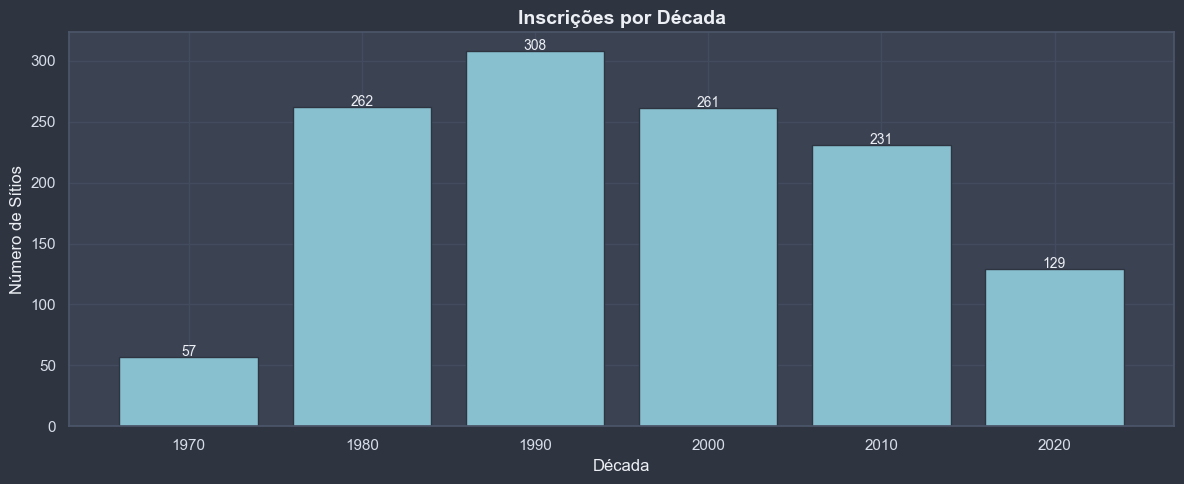

In [13]:
decade_counts = df["decade_inscribed"].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    decade_counts.index.astype(str),
    decade_counts.values,
    color="#88C0D0",
    edgecolor="#2E3440",
)
for bar, val in zip(bars, decade_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        str(int(val)), ha="center", color="#ECEFF4", fontsize=10,
    )
ax.set_title("Inscrições por Década", fontsize=14, fontweight="bold")
ax.set_xlabel("Década")
ax.set_ylabel("Número de Sítios")
plt.tight_layout()
plt.show()

### 10.2 Distribuição por Categoria e Região

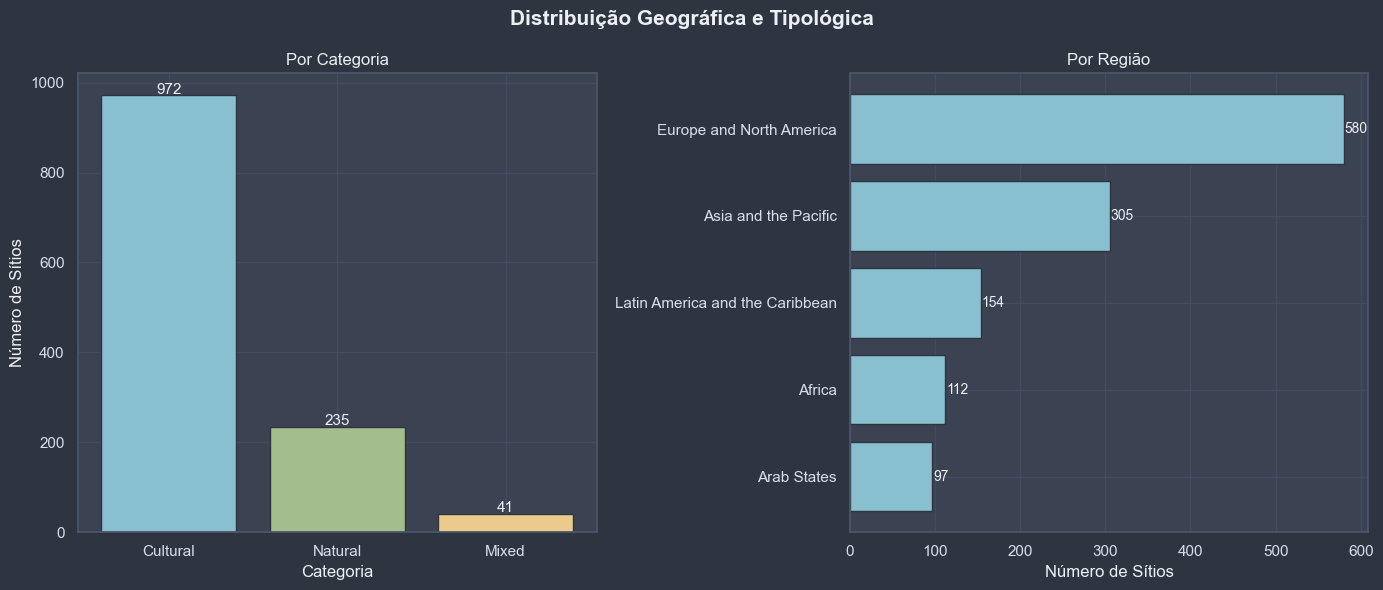

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Categoria
cat_counts = df["category"].value_counts()
ax1.bar(
    cat_counts.index, cat_counts.values,
    color=NORD_PALETTE[: len(cat_counts)], edgecolor="#2E3440",
)
for i, v in enumerate(cat_counts.values):
    ax1.text(i, v + 3, str(v), ha="center", color="#ECEFF4", fontsize=11)
ax1.set_title("Por Categoria")
ax1.set_xlabel("Categoria")
ax1.set_ylabel("Número de Sítios")

# Região
region_counts = df["region"].value_counts().sort_values()
ax2.barh(
    region_counts.index, region_counts.values,
    color="#88C0D0", edgecolor="#2E3440",
)
for i, v in enumerate(region_counts.values):
    ax2.text(v + 1, i, str(v), va="center", color="#ECEFF4", fontsize=10)
ax2.set_title("Por Região")
ax2.set_xlabel("Número de Sítios")

fig.suptitle("Distribuição Geográfica e Tipológica", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 10.3 Critérios de Inscrição — Frequência e Distribuição

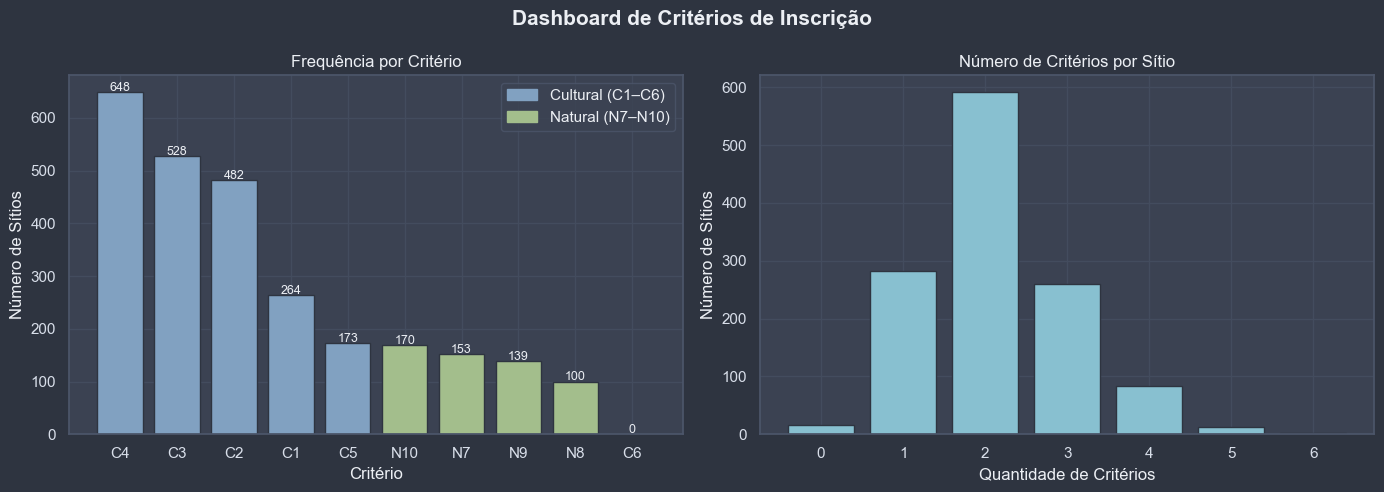

In [15]:
from matplotlib.patches import Patch

# Conta ocorrências individuais de cada critério nas colunas de texto
cultural_keys = {f"c{i}": f"C{i}" for i in range(1, 7)}
natural_keys = {f"n{i}": f"N{i}" for i in range(7, 11)}

criteria_counts = {}
for key, label in cultural_keys.items():
    criteria_counts[label] = (
        df["cultural_criteria"].fillna("").str.lower().str.contains(rf"\b{key}\b").sum()
    )
for key, label in natural_keys.items():
    criteria_counts[label] = (
        df["natural_criteria"].fillna("").str.lower().str.contains(rf"\b{key}\b").sum()
    )

criteria_series = pd.Series(criteria_counts).sort_values(ascending=False)
colors = ["#81A1C1" if c.startswith("C") else "#A3BE8C" for c in criteria_series.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Frequência por critério
bars = ax1.bar(criteria_series.index, criteria_series.values, color=colors, edgecolor="#2E3440")
for bar, val in zip(bars, criteria_series.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        str(int(val)), ha="center", color="#ECEFF4", fontsize=9,
    )
ax1.set_title("Frequência por Critério")
ax1.set_xlabel("Critério")
ax1.set_ylabel("Número de Sítios")
ax1.legend(handles=[
    Patch(color="#81A1C1", label="Cultural (C1–C6)"),
    Patch(color="#A3BE8C", label="Natural (N7–N10)"),
])

# Distribuição do número de critérios por sítio
n_crit_counts = df["n_criteria"].value_counts().sort_index()
ax2.bar(n_crit_counts.index.astype(str), n_crit_counts.values, color="#88C0D0", edgecolor="#2E3440")
ax2.set_title("Número de Critérios por Sítio")
ax2.set_xlabel("Quantidade de Critérios")
ax2.set_ylabel("Número de Sítios")

fig.suptitle("Dashboard de Critérios de Inscrição", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 10.4 Dispersão Geográfica dos Sítios

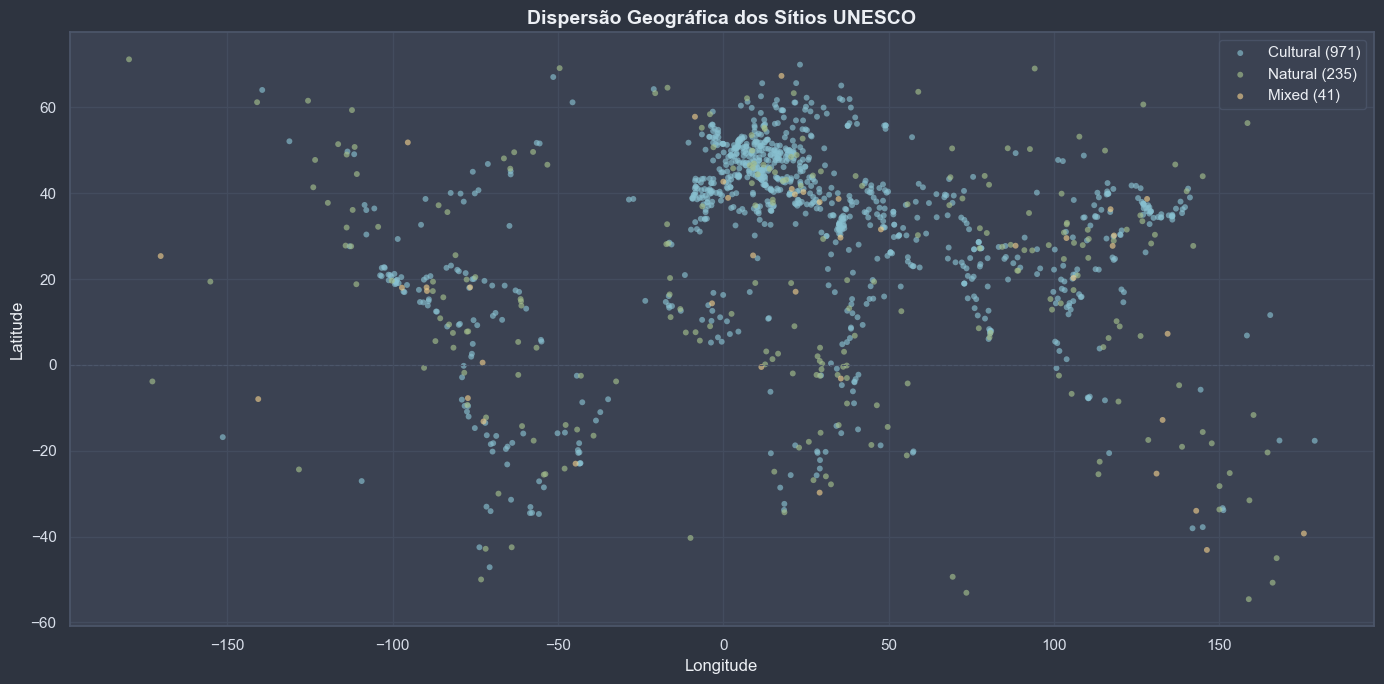

Sítios com coordenadas: 1,247 / 1,248


In [16]:
geo_df = df.dropna(subset=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(14, 7))
for cat, color in zip(["Cultural", "Natural", "Mixed"], NORD_PALETTE):
    mask = geo_df["category"] == cat
    ax.scatter(
        geo_df.loc[mask, "longitude"],
        geo_df.loc[mask, "latitude"],
        c=color, label=f"{cat} ({mask.sum()})",
        alpha=0.65, s=18, edgecolors="none",
    )
ax.axhline(0, color="#4C566A", linewidth=0.8, linestyle="--")
ax.set_title("Dispersão Geográfica dos Sítios UNESCO", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sítios com coordenadas: {len(geo_df):,} / {len(df):,}")

### 10.5 Distribuição de Área (escala log)

/tmp/ipykernel_2279/1883875338.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_2279/1883875338.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/home/leandro/programacao/unesco_sites/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leandro/programacao/unesco_sites/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


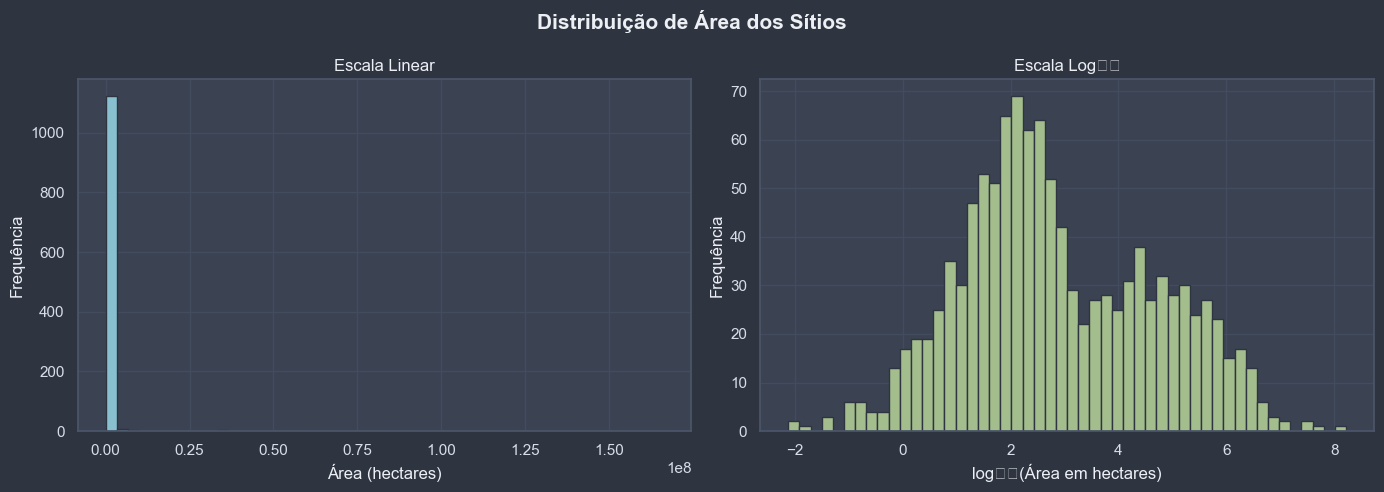

Mediana: 351 ha  |  Média: 423,046 ha  |  Máx: 166,267,100 ha


In [17]:
area_series = df["area_hectares"].dropna()
area_series = area_series[area_series > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(area_series, bins=50, color="#88C0D0", edgecolor="#2E3440")
ax1.set_title("Escala Linear")
ax1.set_xlabel("Área (hectares)")
ax1.set_ylabel("Frequência")

ax2.hist(np.log10(area_series), bins=50, color="#A3BE8C", edgecolor="#2E3440")
ax2.set_title("Escala Log₁₀")
ax2.set_xlabel("log₁₀(Área em hectares)")
ax2.set_ylabel("Frequência")

fig.suptitle("Distribuição de Área dos Sítios", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Mediana: {area_series.median():,.0f} ha  |  Média: {area_series.mean():,.0f} ha  |  Máx: {area_series.max():,.0f} ha")

### 10.6 Sítios em Perigo — Análise por Região e Evolução Temporal

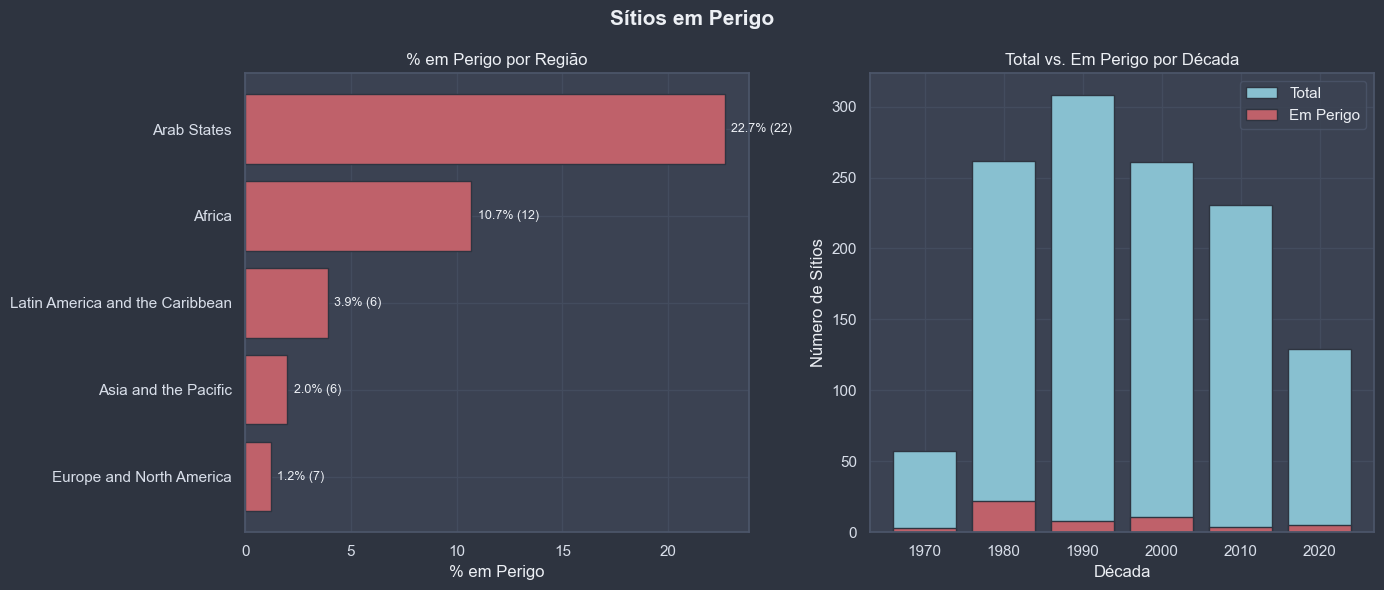

Total em perigo: 53 (4.2%)


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# % em perigo por região
danger_by_region = (
    df.groupby("region")["is_endangered"]
    .agg(endangered="sum", total="count")
    .assign(pct=lambda x: (x["endangered"] / x["total"] * 100).round(1))
    .sort_values("pct")
)
ax1.barh(
    danger_by_region.index, danger_by_region["pct"],
    color="#BF616A", edgecolor="#2E3440",
)
for i, (_, row) in enumerate(danger_by_region.iterrows()):
    ax1.text(
        row["pct"] + 0.3, i,
        f"{row['pct']:.1f}% ({int(row['endangered'])})",
        va="center", color="#ECEFF4", fontsize=9,
    )
ax1.set_title("% em Perigo por Região")
ax1.set_xlabel("% em Perigo")

# Evolução dos sítios em perigo por década
danger_temporal = (
    df.groupby("decade_inscribed")["is_endangered"]
    .agg(endangered="sum", total="count")
    .dropna()
)
x = danger_temporal.index.astype(str)
ax2.bar(x, danger_temporal["total"], color="#88C0D0", label="Total", edgecolor="#2E3440")
ax2.bar(x, danger_temporal["endangered"], color="#BF616A", label="Em Perigo", edgecolor="#2E3440")
ax2.set_title("Total vs. Em Perigo por Década")
ax2.set_xlabel("Década")
ax2.set_ylabel("Número de Sítios")
ax2.legend()

fig.suptitle("Sítios em Perigo", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

total_endangered = df["is_endangered"].sum()
print(f"Total em perigo: {total_endangered} ({total_endangered / len(df) * 100:.1f}%)")

### 10.7 Correlação entre Features Numéricas

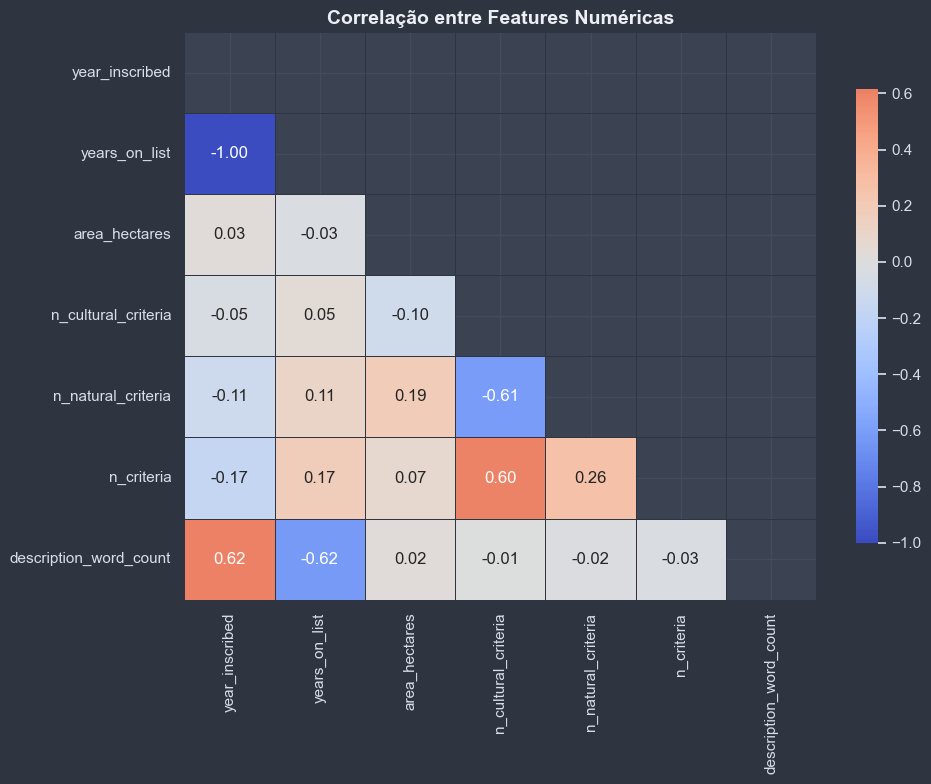

In [19]:
numeric_features = [
    "year_inscribed", "years_on_list", "area_hectares",
    "n_cultural_criteria", "n_natural_criteria", "n_criteria",
    "description_word_count",
]
available = [c for c in numeric_features if c in df.columns]
corr = df[available].astype(float).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
    linecolor="#2E3440",
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlação entre Features Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
PROCESSED_PATH = Path("..") / "data" / "processed" / "whc_processed.csv"

df.to_csv(PROCESSED_PATH, index=False, sep=";", encoding="utf-8")

print(f"Salvo em : {PROCESSED_PATH}")
print(f"Shape    : {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Salvo em : ../data/processed/whc_processed.csv
Shape    : 1,248 linhas × 46 colunas
